In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import seaborn as sns

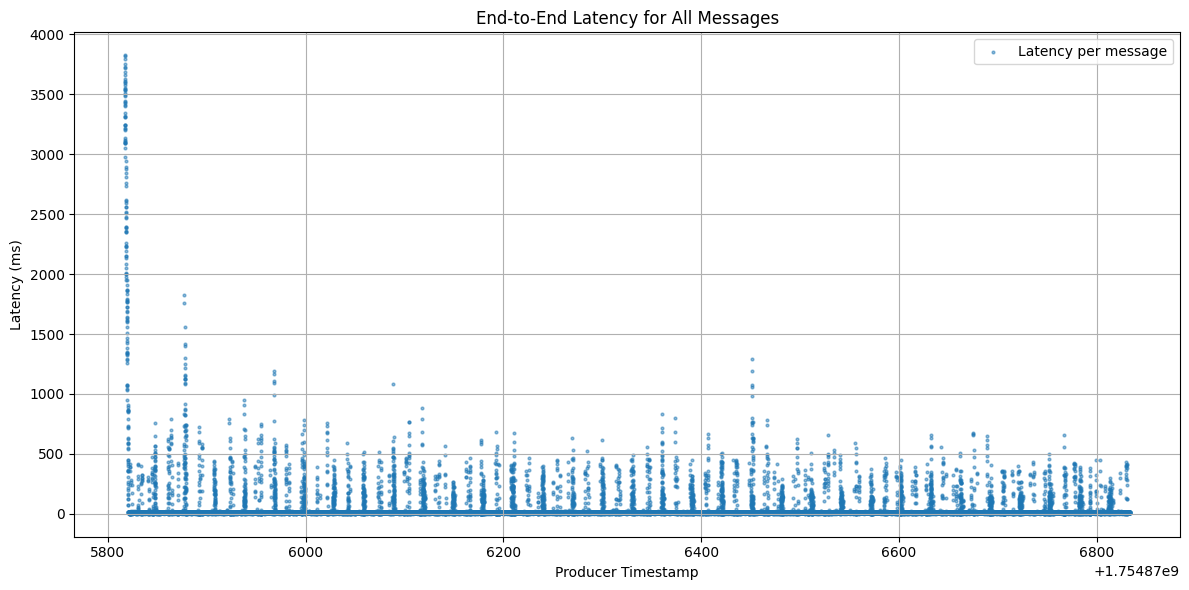

In [23]:


# Directory containing batch CSVs
#target_dir = './20250808_153041/consumer/consumer-sts-0_consumer-result/2025-08-08/15-07-39/'
target_dir = './20250808_170613/consumer/consumer-sts-0_consumer-result/2025-08-08/15-07-40/'
target_dir = './20250809_191915/consumer/consumer-sts-0_consumer-result/2025-08-09/18-37-37'
target_dir = './20250810_174112/consumer/consumer-sts-0_consumer-result/2025-08-10/13-41-41/'
target_dir = './20250810_194823/consumer/consumer-sts-0_consumer-result/2025-08-10/19-30-13/'

# List to hold all individual latency entries
all_latencies = []

# Read all batch CSV files
for file_path in glob.glob(os.path.join(target_dir, 'batch_consumer-*.csv')):
    try:
        df = pd.read_csv(file_path)

        if len(df) == 0:
            continue

        # Clean size_bytes column if it's a string like "123b"
        df['size_bytes'] = df['size_bytes'].apply(lambda x: int(str(x).strip("b'")))

        # Extract only the required columns for plotting latency
        all_latencies.append(df[['producer_timestamp', 'end_to_end_latency_seconds']])
    except Exception as e:
        print(f"[ERROR] Failed to process {file_path}: {e}")

# Combine all individual latency entries into a single DataFrame
latency_df = pd.concat(all_latencies, ignore_index=True)

# Convert latency from seconds to milliseconds
latency_df['latency_ms'] = latency_df['end_to_end_latency_seconds'] * 1000
latency_df = latency_df[latency_df['latency_ms'] < 5000]

# Sort by timestamp
latency_df = latency_df.sort_values('producer_timestamp')



# Plot: All latency points
plt.figure(figsize=(12, 6))
plt.scatter(latency_df['producer_timestamp'], latency_df['latency_ms'], 
            s=4, alpha=0.5, label='Latency per message')

plt.title('End-to-End Latency for All Messages')
plt.xlabel('Producer Timestamp')
plt.ylabel('Latency (ms)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


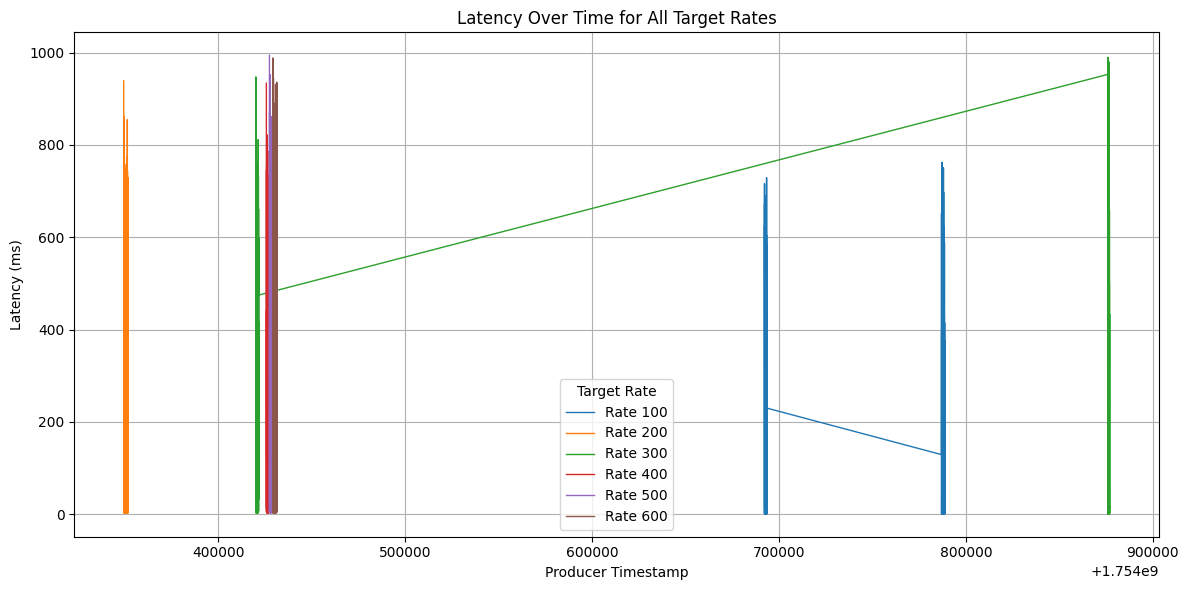

✅ Combined plot saved to: /Users/soheila/Desktop/plots/latency_all_rates.jpeg


In [27]:

# List of directories for each target rate
target_dirs = [
    #'./20250804_161303/consumer/consumer-sts-0_consumer-result/2025-08-04/14-29-50/',  # target rate = 10
    #'./20250804_161303/consumer/consumer-sts-0_consumer-result/2025-08-04/15-51-30/',  # target rate = 1069
    './20250804_175641/consumer/consumer-sts-0_consumer-result/2025-08-04/17-15-36/',  # target rate = 200
    './20250805_134039/consumer/consumer-sts-0_consumer-result/2025-08-05/12-53-26/',  # target rate = 300
    './20250805_144929/consumer/consumer-sts-0_consumer-result/2025-08-05/14-27-52-TR-400/',  # target rate = 400
    './20250805_151836/consumer/consumer-sts-0_consumer-result/2025-08-05/14-55-21-TR-500/',  # target rate = 500
    './20250805_160643/consumer/consumer-sts-0_consumer-result/2025-08-05/15-25-15-TR-600/',  # target rate = 600
    './20250808_170613/consumer/consumer-sts-0_consumer-result/2025-08-08/15-07-40/', # target rate = 100
    './20250809_191915/consumer/consumer-sts-0_consumer-result/2025-08-09/18-37-37', # target rate = 100
    './20250810_194823/consumer/consumer-sts-0_consumer-result/2025-08-10/19-30-13/'
]

latency_dfs = []

# Loop through all target directories
for target_dir in target_dirs:
    for file_path in glob.glob(os.path.join(target_dir, 'batch_consumer-*.csv')):
        try:
            df = pd.read_csv(file_path)
            if df.empty:
                continue

            df['size_bytes'] = df['size_bytes'].apply(lambda x: int(str(x).strip("b'")) if isinstance(x, str) else int(x))
            df['latency_ms'] = df['end_to_end_latency_seconds'] * 1000

            # Add to global list
            latency_dfs.append(df[['producer_timestamp', 'latency_ms', 'target_rate']])

        except Exception as e:
            print(f"[ERROR] Failed to process {file_path}: {e}")

# Combine all data
summary_df = pd.concat(latency_dfs, ignore_index=True)

# Optional: remove extreme outliers
summary_df = summary_df[summary_df['latency_ms'] < 1000]  # or < 1000

# Sort by time
summary_df = summary_df.sort_values('producer_timestamp')
# Convert timestamps if needed
# summary_df['timestamp'] = pd.to_datetime(summary_df['producer_timestamp'], unit='s')

plt.figure(figsize=(12, 6))
for rate in sorted(summary_df['target_rate'].unique()):
    sub_df = summary_df[summary_df['target_rate'] == rate]
    plt.plot(sub_df['producer_timestamp'], sub_df['latency_ms'], label=f"Rate {int(rate)}", linewidth=1)

plt.title("Latency Over Time for All Target Rates")
plt.xlabel("Producer Timestamp")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.legend(title="Target Rate")
plt.tight_layout()

# Save the plot
desktop_path = os.path.expanduser("~/Desktop/plots")
os.makedirs(desktop_path, exist_ok=True)
plot_path = os.path.join(desktop_path, "latency_all_rates.jpeg")
plt.savefig(plot_path, format='jpeg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"✅ Combined plot saved to: {plot_path}")




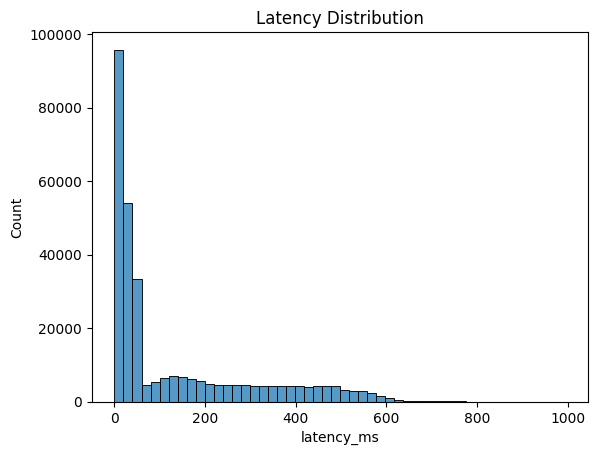

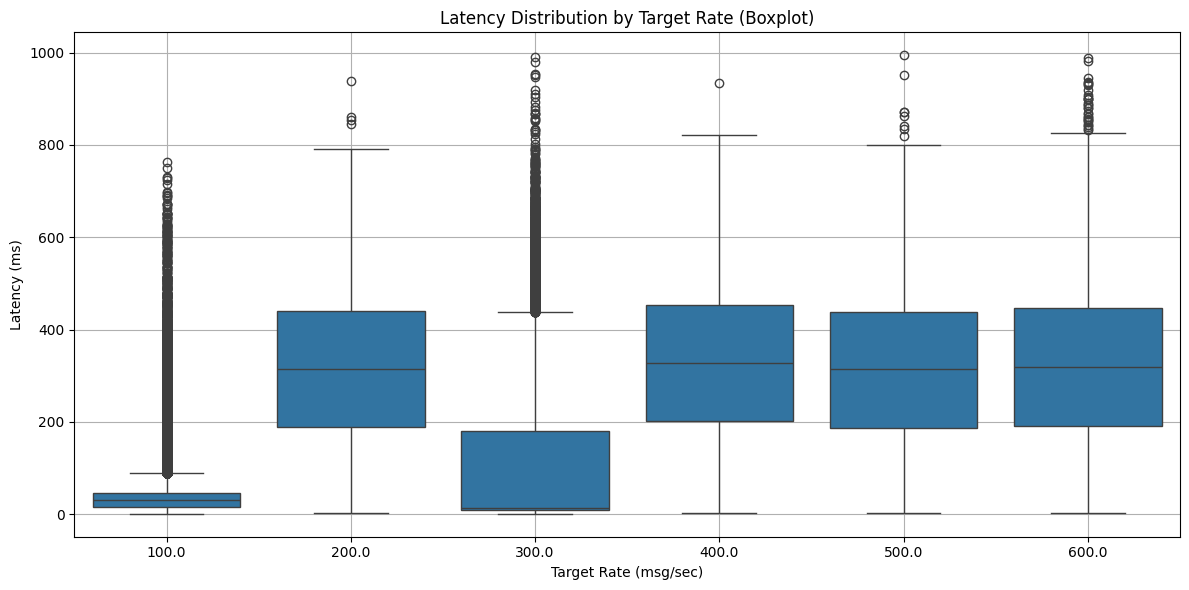

In [28]:

sns.histplot(summary_df['latency_ms'], bins=50)
plt.title("Latency Distribution")
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=summary_df, x='target_rate', y='latency_ms')

plt.title('Latency Distribution by Target Rate (Boxplot)')
plt.xlabel('Target Rate (msg/sec)')
plt.ylabel('Latency (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
print(latency_df['latency_ms'].describe())
print("Max latency (ms):", latency_df['latency_ms'].max())

count    47700.000000
mean        32.747298
std        150.142352
min          0.758410
25%          8.423269
50%         11.323929
75%         14.419317
max       3824.491739
Name: latency_ms, dtype: float64
Max latency (ms): 3824.4917392730713
